In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# --- Style ---

axis_label_font_size = 7
tick_label_font_size = 6
anno_font_size = 5
plt.rcParams.update({
    'font.size': axis_label_font_size,
    'axes.titlesize': axis_label_font_size,
    'axes.labelsize': axis_label_font_size,
    'xtick.labelsize': tick_label_font_size,
    'ytick.labelsize': tick_label_font_size,
    'legend.fontsize': tick_label_font_size,
    'legend.title_fontsize': axis_label_font_size,
})

# --- Input path ---
ANNOTATED_SNP_TABLE = 'intermediate_data/fig5_panel_a_ai_hla_zoomed_snp_annotated_trimmed.csv'

# --- Output path ---
FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)

# --- HLA subregion boundaries (hg19) ---
HLA_REGIONS = {
    "HLA-A":    (29_909_037, 29_917_349),
    "HLA-B":    (31_321_649, 31_334_844),
    "HLA-C":    (31_236_526, 31_239_907),
    "HLA-DRA":  (324_076_55, 324_128_23),
    "HLA-DRB1": (325_456_79, 325_576_25),
    "HLA-DQA1": (325_959_56, 326_148_39),
    "HLA-DQB1": (326_272_44, 326_361_60),
    "HLA-DPA1": (330_323_46, 330_485_52),
    "HLA-DPB1": (330_437_13, 330_574_73),
}
MHC_START = 29_500_000
MHC_END = 33_500_000

/var/folders/lm/b7fcsstn40g11jvck0m209_8fjcxsl/T/ipykernel_24722/184808405.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


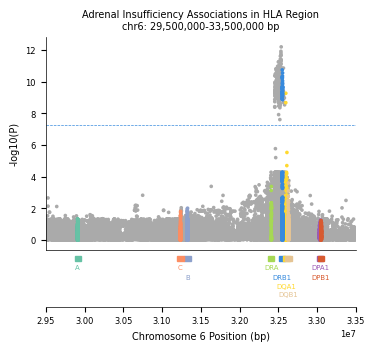

In [3]:
def plot_hla_zoomed_regional_association(
    snp_table_path=ANNOTATED_SNP_TABLE,
    hla_regions=HLA_REGIONS,
    mhc_start=MHC_START,
    mhc_end=MHC_END,
    figure_dir=FIGURE_DIR,
):
    """ HLA-region regional-association plot (scatter of
    -log10(P) vs. genomic position, with a gene track below) from the
    annotated SNP table"""
    mhc_snps = pd.read_csv(snp_table_path)

    # ── Color maps ──────────────────────────────────────────────────────
    gene_colors = plt.cm.Set2.colors

    LOCUS_COLORS = {
        "HLA-A":      gene_colors[0],
        "HLA-C":      gene_colors[1],
        "HLA-B":      gene_colors[2],
        "MICA/MICB":  gene_colors[3],
        "HLA-DRA":    gene_colors[4],
        "HLA-DRB1":   '#378ADD',
        "HLA-DQA1":   gene_colors[5],
        "HLA-DQB1":   gene_colors[6],
        "HLA-DPA1":   "#9B59B6",
        "HLA-DPB1":   "#D85A30",
        "Intergenic": "#AAAAAA",
        "Non-MHC":    "#AAAAAA",
        "Unknown":    "#AAAAAA",
    }

    LABEL_MAP = {
        "HLA-A": "A",
        "HLA-C": "C",
        "HLA-B": "B",
        "MICA/MICB": "MICA",
        "HLA-DRA": "DRA", "HLA-DRB1": "DRB1",
        "HLA-DQA1": "DQA1", "HLA-DQB1": "DQB1",
        "HLA-DPA1": "DPA1", "HLA-DPB1": "DPB1",
    }

    MANUAL_LEVELS = {
        "HLA-A": 0, "HLA-C": 0, "HLA-B": 1,
        "MICA/MICB": 0, "HLA-DRA": 0, "HLA-DRB1": 1,
        "HLA-DQA1": 2, "HLA-DQB1": 3, "HLA-DPA1": 0, "HLA-DPB1": 1,
    }

    # ── Layout constants ───────────────────────────────────────────────
    LW = 0.5
    TRACK_Y = 0.6
    BOX_H = 0.45
    MIN_BOX_WIDTH = 80_000
    Y_OFFSETS = [-0.00, -0.85, -1.65, -2.45, -5.25]

    # ── Figure setup ────────────────────────────────────────────────────
    fig, (ax, ax_track) = plt.subplots(
        2, 1, figsize=(4, 3.5),
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.03},
    )

    # ── Main scatter panel ─────────────────────────────────────────────
    mhc_snps["logP"] = -np.log10(mhc_snps["p.value.spa"].astype(float))
    y_col = "logP"
    ax.set_ylabel("-log10(P)", fontsize=axis_label_font_size)

    for locus, group in mhc_snps.groupby("HLA_locus"):
        is_bg = locus in ("Intergenic", "Non-MHC")
        ax.scatter(
            group["BP"], group[y_col],
            color=LOCUS_COLORS[locus],
            label=locus,
            s=7,
            rasterized=True,
            alpha=1.0,
            edgecolors="none",
            zorder=1 if is_bg else 2,
        )

    if y_col == "logP":
        ax.axhline(y=7.3, color='#378ADD', linestyle="--", linewidth=LW, label="p=5e-8")

    ax.set_xlim(mhc_start, mhc_end)
    ax.set_title(
        "Adrenal Insufficiency Associations in HLA Region\nchr6: 29,500,000-33,500,000 bp",
        fontsize=axis_label_font_size
    )
    ax.tick_params(axis="x", labelbottom=False, length=0, labelsize=tick_label_font_size)
    ax.tick_params(axis="y", labelsize=tick_label_font_size)
    ax.xaxis.offsetText.set_visible(False)
    ax.yaxis.offsetText.set_fontsize(axis_label_font_size)
    ax.set_xlabel("")
    sns.despine(ax=ax)

    for spine in ax.spines.values():
        spine.set_linewidth(LW)

    # ── Gene track panel ───────────────────────────────────────────────
    ax_track.set_xlim(mhc_start, mhc_end)
    ax_track.set_ylim(-3.8, 1)
    ax_track.yaxis.set_visible(False)
    for spine in ("top", "right", "left"):
        ax_track.spines[spine].set_visible(False)
    ax_track.spines["bottom"].set_linewidth(LW)

    for gene, (start, end) in hla_regions.items():
        mid = (start + end) / 2
        display_width = max(end - start, MIN_BOX_WIDTH)
        rect = mpatches.Rectangle(
            (mid - display_width / 2, TRACK_Y - BOX_H / 2),
            display_width, BOX_H,
            color=LOCUS_COLORS.get(gene, "#AAAAAA"),
            clip_on=False,
        )
        ax_track.add_patch(rect)

    for gene, (start, end) in sorted(hla_regions.items(), key=lambda x: x[1][0]):
        mid = (start + end) / 2
        ax_track.text(
            mid, Y_OFFSETS[MANUAL_LEVELS[gene]],
            LABEL_MAP.get(gene, gene),
            ha="center", va="top",
            fontsize=anno_font_size,
            color=LOCUS_COLORS.get(gene, "#AAAAAA"),
            clip_on=False,
        )

    ax_track.set_xlim(mhc_start, mhc_end)
    ax_track.set_xlabel("Chromosome 6 Position (bp)", fontsize=axis_label_font_size)
    ax_track.tick_params(axis='x', labelsize=tick_label_font_size)
    ax_track.tick_params(axis='y', labelsize=tick_label_font_size)
    ax_track.xaxis.offsetText.set_fontsize(tick_label_font_size)

    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, "fig5_panel_a_ai_hla_zoomed_in_top_snp_map.pdf"), dpi=300)
    plt.savefig(os.path.join(figure_dir, "fig5_panel_a_ai_hla_zoomed_in_top_snp_map.png"), dpi=300)

    return fig


_ = plot_hla_zoomed_regional_association()
